# Four Probe Method

In [282]:
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable

### Data

In [283]:
#n-type Silicon
I1 = np.array([0,10.2,20.0,30.0,40,50.4,60,70.5,80.2,90.3,99.9,110.0,120.4,130.0,140.4,150.0,160.1,170.0,180.0])
V1 = np.array([0.7,1.9,3.1,4.4,5.6,6.9,8.1,9.4,10.6,11.9,13.0,14.3,15.6,16.8,18.1,19.3,20.6,21.8,23.1])
V1 = V1 - 0.7

#n-type Germanium
I2 = np.array([0.39,0.90,1.12,1.42,1.88,2.20,2.66,3.33,4.11,4.39,4.69,5.04,5.62,6.02,6.19])
V2 = np.array([0.041,0.088,0.108,0.136,0.178,0.207,0.252,0.314,0.389,0.414,0.443,0.475,0.529,0.568,0.585])

#Al
I3 = np.array([4.0,10.1,21.1,29.7,40.5,50.1,60.0,71.0,80.4,90.1,100.4,111.1,122.3,130.2,140.8,150.6,160.0,169.7,180.2,190.1])
V3 = np.array([0,0.002,0.006,0.009,0.014,0.016,0.020,0.025,0.028,0.032,0.036,0.039,0.044,0.046,0.050,0.054,0.056,0.060,0.064,0.067])

#Temperature dependence
#Al foil
T3 = np.array([27,30,35,40,45,50,60,65,70,75,80])
T3 = T3 + 273.15
V_3 = np.array([0.060,0.061,0.063,0.067,0.060,0.057,0.056,0.057,0.055,0.064,0.078])

#n-type Germanium 
T2 = np.array([118,125,130,135,140,145,150,155,160,165,170,175,180])
T2 = T2 + 273.15 
V_2 = np.array([0.055,0.047,0.041,0.039,0.032,0.029,0.025,0.022,0.020,0.018,0.016,0.014,0.013])

## Linear Fits


+-------------------------------------+
|              Input Data             |
+----+-------+-------+-------+--------+
| i  |   x   |   y   |   x²  |   xy   |
+----+-------+-------+-------+--------+
| 1  |  0.0  |  0.0  |  0.0  |  0.0   |
| 2  |  0.01 |  1.2  |  0.0  | 0.012  |
| 3  |  0.02 |  2.4  |  0.0  | 0.048  |
| 4  |  0.03 |  3.7  | 0.001 | 0.111  |
| 5  |  0.04 |  4.9  | 0.002 | 0.196  |
| 6  |  0.05 |  6.2  | 0.003 | 0.312  |
| 7  |  0.06 |  7.4  | 0.004 | 0.444  |
| 8  |  0.07 |  8.7  | 0.005 | 0.613  |
| 9  |  0.08 |  9.9  | 0.006 | 0.794  |
| 10 |  0.09 |  11.2 | 0.008 | 1.011  |
| 11 |  0.1  |  12.3 |  0.01 | 1.229  |
| 12 |  0.11 |  13.6 | 0.012 | 1.496  |
| 13 |  0.12 |  14.9 | 0.014 | 1.794  |
| 14 |  0.13 |  16.1 | 0.017 | 2.093  |
| 15 |  0.14 |  17.4 |  0.02 | 2.443  |
| 16 |  0.15 |  18.6 | 0.022 |  2.79  |
| 17 |  0.16 |  19.9 | 0.026 | 3.186  |
| 18 |  0.17 |  21.1 | 0.029 | 3.587  |
| 19 |  0.18 |  22.4 | 0.032 | 4.032  |
| Σ  | 1.712 | 211.9 | 0.211 | 26.192 |


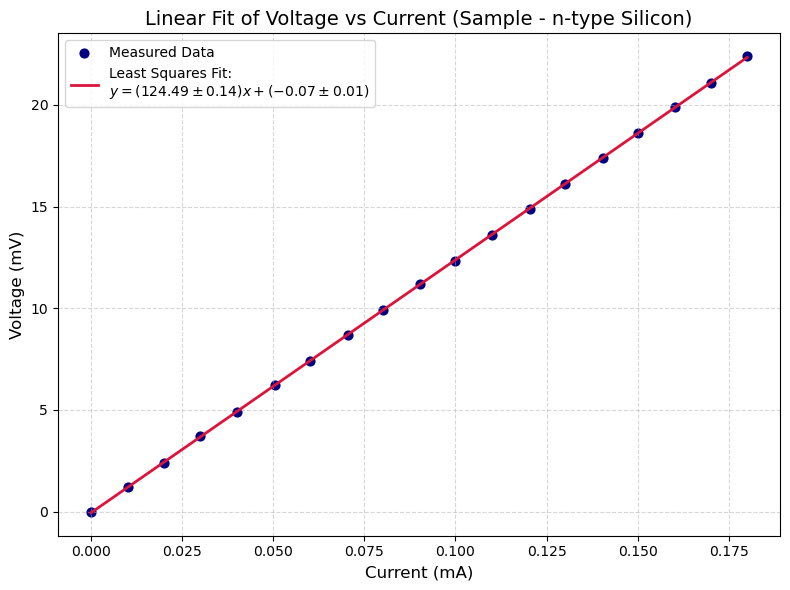

In [284]:
x = I1*1e-3
y = V1 
n = len(x)

# --- Data Table ---
table_data = PrettyTable(["i", "x", "y", "x²", "xy"])
for i in range(n):
    table_data.add_row([i+1, round(x[i], 3), round(y[i], 3), round(x[i]**2, 3), round(x[i]*y[i], 3)])
table_data.add_row(["Σ", round(np.sum(x), 3), round(np.sum(y), 3), round(np.sum(x**2), 3), round(np.sum(x*y), 3)])
table_data.title = "Input Data"
print(table_data, "\n")

# --- Least Squares Calculation ---
Sx = np.sum(x)
Sy = np.sum(y)
Sxx = np.sum(x**2)
Sxy = np.sum(x*y)

delta = n*Sxx - Sx**2
a1 = (n*Sxy - Sx*Sy) / delta  # Slope
a0 = (Sxx*Sy - Sx*Sxy) / delta  # Intercept

# --- Error Analysis ---
y_fit = a0 + a1*x
residuals = y - y_fit
sigma_y = np.sqrt(np.sum(residuals**2) / (n-2))
sigma_a1 = sigma_y * np.sqrt(n / delta)
sigma_a0 = sigma_y * np.sqrt(Sxx / delta)

# --- Results Table ---
results = PrettyTable(["Parameter", "Value", "Uncertainty"])
results.title = "Fit Results & Statistical Errors"
results.add_row(["Slope (a₁)", f"{a1:.2f}", f"±{sigma_a1:.2f}"])
results.add_row(["Intercept (a₀)", f"{a0:.2f}", f"±{sigma_a0:.2f}"])
results.add_row(["σ_y (Std. Error)", f"{sigma_y:.2f}", ""])
results.add_row(["Δ (delta)", f"{delta:.2f}", ""])
print(results, "\n")

# --- Fitted Values Table ---
fit_table = PrettyTable(["x", "y (measured)", "y (fit)"])
fit_table.title = "Measured vs Fitted Values"
for xi, yi, yfi in zip(x, y, y_fit):
    fit_table.add_row([round(xi, 3), round(yi, 3), round(yfi, 3)])
print(fit_table, "\n")

# --- Plotting ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='navy', label='Measured Data', s=40)
plt.plot(x, y_fit, color='crimson', linewidth=2,
         label=f'Least Squares Fit:\n$y = ({a1:.2f} \pm {sigma_a1:.2f})x + ({a0:.2f} \pm {sigma_a0:.2f})$')
plt.xlabel(r'Current (mA)', fontsize=12)
plt.ylabel(r'Voltage (mV)', fontsize=12)
plt.title(r"Linear Fit of Voltage vs Current (Sample - n-type Silicon)", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

+-------------------------------------------+
|                 Input Data                |
+----+---------+-------+----------+---------+
| i  |    x    |   y   |    x²    |    xy   |
+----+---------+-------+----------+---------+
| 1  | 0.00039 | 0.041 |  2e-07   |  2e-05  |
| 2  |  0.0009 | 0.088 |  8e-07   |  8e-05  |
| 3  | 0.00112 | 0.108 | 1.3e-06  | 0.00012 |
| 4  | 0.00142 | 0.136 |  2e-06   | 0.00019 |
| 5  | 0.00188 | 0.178 | 3.5e-06  | 0.00033 |
| 6  |  0.0022 | 0.207 | 4.8e-06  | 0.00046 |
| 7  | 0.00266 | 0.252 | 7.1e-06  | 0.00067 |
| 8  | 0.00333 | 0.314 | 1.11e-05 | 0.00105 |
| 9  | 0.00411 | 0.389 | 1.69e-05 |  0.0016 |
| 10 | 0.00439 | 0.414 | 1.93e-05 | 0.00182 |
| 11 | 0.00469 | 0.443 | 2.2e-05  | 0.00208 |
| 12 | 0.00504 | 0.475 | 2.54e-05 | 0.00239 |
| 13 | 0.00562 | 0.529 | 3.16e-05 | 0.00297 |
| 14 | 0.00602 | 0.568 | 3.62e-05 | 0.00342 |
| 15 | 0.00619 | 0.585 | 3.83e-05 | 0.00362 |
| Σ  | 0.04996 | 4.727 | 0.00022  | 0.02082 |
+----+---------+-------+----------

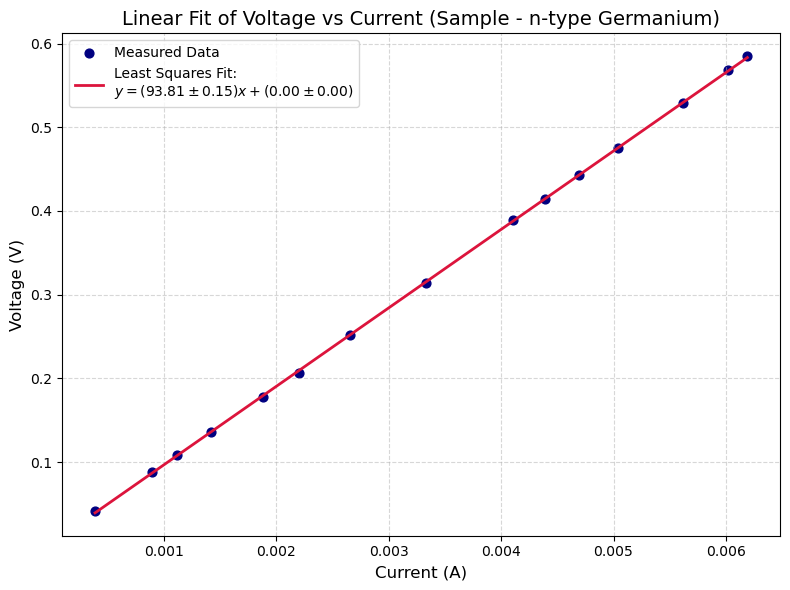

In [285]:
x = I2*1e-3
y = V2 
n = len(x)

# --- Data Table ---
table_data = PrettyTable(["i", "x", "y", "x²", "xy"])
for i in range(n):
    table_data.add_row([i+1, round(x[i], 5), round(y[i], 5), round(x[i]**2, 7), round(x[i]*y[i], 5)])
table_data.add_row(["Σ", round(np.sum(x), 5), round(np.sum(y), 5), round(np.sum(x**2), 5), round(np.sum(x*y), 5)])
table_data.title = "Input Data"
print(table_data, "\n")

# --- Least Squares Calculation ---
Sx = np.sum(x)
Sy = np.sum(y)
Sxx = np.sum(x**2)
Sxy = np.sum(x*y)

delta = n*Sxx - Sx**2
a1 = (n*Sxy - Sx*Sy) / delta  # Slope
a0 = (Sxx*Sy - Sx*Sxy) / delta  # Intercept

# --- Error Analysis ---
y_fit = a0 + a1*x
residuals = y - y_fit
sigma_y = np.sqrt(np.sum(residuals**2) / (n-2))
sigma_a1 = sigma_y * np.sqrt(n / delta)
sigma_a0 = sigma_y * np.sqrt(Sxx / delta)

# --- Results Table ---
results = PrettyTable(["Parameter", "Value", "Uncertainty"])
results.title = "Fit Results & Statistical Errors"
results.add_row(["Slope (a₁)", f"{a1:.2f}", f"±{sigma_a1:.2f}"])
results.add_row(["Intercept (a₀)", f"{a0:.2f}", f"±{sigma_a0:.2f}"])
results.add_row(["σ_y (Std. Error)", f"{sigma_y:.2f}", ""])
results.add_row(["Δ (delta)", f"{delta:.2f}", ""])
print(results, "\n")

# --- Fitted Values Table ---
fit_table = PrettyTable(["x", "y (measured)", "y (fit)"])
fit_table.title = "Measured vs Fitted Values"
for xi, yi, yfi in zip(x, y, y_fit):
    fit_table.add_row([round(xi, 5), round(yi, 5), round(yfi, 5)])
print(fit_table, "\n")

# --- Plotting ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='navy', label='Measured Data', s=40)
plt.plot(x, y_fit, color='crimson', linewidth=2,
         label=f'Least Squares Fit:\n$y = ({a1:.2f} \pm {sigma_a1:.2f})x + ({a0:.2f} \pm {sigma_a0:.2f})$')
plt.xlabel(r'Current (A)', fontsize=12)
plt.ylabel(r'Voltage (V)', fontsize=12)
plt.title(r"Linear Fit of Voltage vs Current (Sample - n-type Germanium)", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

+------------------------------------------+
|                Input Data                |
+----+--------+-------+-----------+--------+
| i  |   x    |   y   |     x²    |   xy   |
+----+--------+-------+-----------+--------+
| 1  |  4.0   |  0.0  |    16.0   |  0.0   |
| 2  |  10.1  | 0.002 |   102.01  |  0.02  |
| 3  |  21.1  | 0.006 |   445.21  | 0.127  |
| 4  |  29.7  | 0.009 |   882.09  | 0.267  |
| 5  |  40.5  | 0.014 |  1640.25  | 0.567  |
| 6  |  50.1  | 0.016 |  2510.01  | 0.802  |
| 7  |  60.0  |  0.02 |   3600.0  |  1.2   |
| 8  |  71.0  | 0.025 |   5041.0  | 1.775  |
| 9  |  80.4  | 0.028 |  6464.16  | 2.251  |
| 10 |  90.1  | 0.032 |  8118.01  | 2.883  |
| 11 | 100.4  | 0.036 |  10080.16 | 3.614  |
| 12 | 111.1  | 0.039 |  12343.21 | 4.333  |
| 13 | 122.3  | 0.044 |  14957.29 | 5.381  |
| 14 | 130.2  | 0.046 |  16952.04 | 5.989  |
| 15 | 140.8  |  0.05 |  19824.64 |  7.04  |
| 16 | 150.6  | 0.054 |  22680.36 | 8.132  |
| 17 | 160.0  | 0.056 |  25600.0  |  8.96  |
| 18 | 169

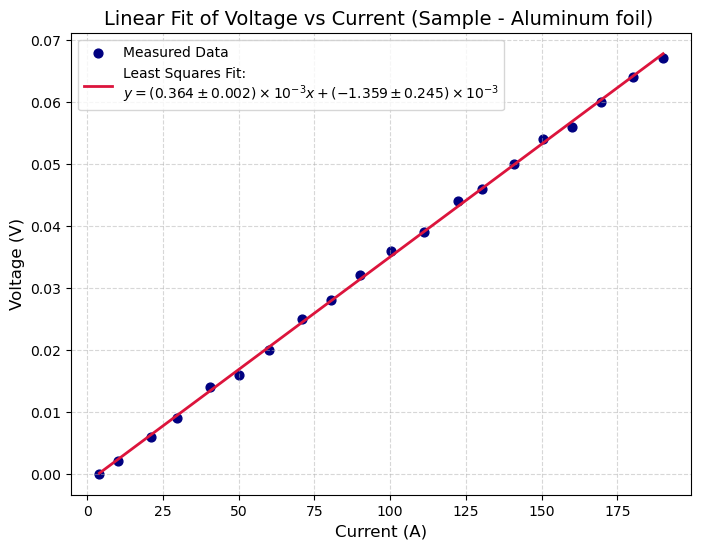

In [286]:
x = I3
y = V3 
n = len(x)

# --- Data Table ---
table_data = PrettyTable(["i", "x", "y", "x²", "xy"])
for i in range(n):
    table_data.add_row([i+1, round(x[i], 3), round(y[i], 3), round(x[i]**2, 3), round(x[i]*y[i], 3)])
table_data.add_row(["Σ", round(np.sum(x), 3), round(np.sum(y), 3), round(np.sum(x**2), 3), round(np.sum(x*y), 3)])
table_data.title = "Input Data"
print(table_data, "\n")

# --- Least Squares Calculation ---
Sx = np.sum(x)
Sy = np.sum(y)
Sxx = np.sum(x**2)
Sxy = np.sum(x*y)

delta = n*Sxx - Sx**2
a1 = (n*Sxy - Sx*Sy) / delta  # Slope
a0 = (Sxx*Sy - Sx*Sxy) / delta  # Intercept

# --- Error Analysis ---
y_fit = a0 + a1*x
residuals = y - y_fit
sigma_y = np.sqrt(np.sum(residuals**2) / (n-2))
sigma_a1 = sigma_y * np.sqrt(n / delta)
sigma_a0 = sigma_y * np.sqrt(Sxx / delta)

# --- Results Table ---
results = PrettyTable(["Parameter", "Value", "Uncertainty"])
results.title = "Fit Results & Statistical Errors"
results.add_row(["Slope (a₁)", f"{a1:.7f}", f"±{sigma_a1:.7f}"])
results.add_row(["Intercept (a₀)", f"{a0:.7f}", f"±{sigma_a0:.7f}"])
results.add_row(["σ_y (Std. Error)", f"{sigma_y:.7f}", ""])
results.add_row(["Δ (delta)", f"{delta:.7f}", ""])
print(results, "\n")

# --- Fitted Values Table ---
fit_table = PrettyTable(["x", "y (measured)", "y (fit)"])
fit_table.title = "Measured vs Fitted Values"
for xi, yi, yfi in zip(x, y, y_fit):
    fit_table.add_row([round(xi, 3), round(yi, 3), round(yfi, 3)])
print(fit_table, "\n")

# --- Plotting ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='navy', label='Measured Data', s=40)
plt.plot(x, y_fit, color='crimson', linewidth=2,
         label=f'Least Squares Fit:\n$y = ({a1*1e3:.3f} \\pm {sigma_a1*1e3:.3f}) \\times 10^{{-3}} x + ({a0*1e3:.3f} \\pm {sigma_a0*1e3:.3f}) \\times 10^{{-3}}$')
plt.xlabel(r'Current (A)', fontsize=12)
plt.ylabel(r'Voltage (V)', fontsize=12)
plt.title(r"Linear Fit of Voltage vs Current (Sample - Aluminum foil) ", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Temperature dependence

+-----------------------------------------------+
|                   Input Data                  |
+----+---------+-----------+---------+----------+
| i  |    x    |     y     |    x²   |    xy    |
+----+---------+-----------+---------+----------+
| 1  | 0.00256 |  -4.16177 | 6.5e-06 | -0.01064 |
| 2  | 0.00251 |  -4.31895 | 6.3e-06 | -0.01085 |
| 3  | 0.00248 |  -4.45553 | 6.2e-06 | -0.01105 |
| 4  | 0.00245 |  -4.50554 |  6e-06  | -0.01104 |
| 5  | 0.00242 |  -4.70337 | 5.9e-06 | -0.01138 |
| 6  | 0.00239 |  -4.80181 | 5.7e-06 | -0.01148 |
| 7  | 0.00236 |  -4.95023 | 5.6e-06 | -0.0117  |
| 8  | 0.00234 |  -5.07806 | 5.5e-06 | -0.01186 |
| 9  | 0.00231 |  -5.17337 | 5.3e-06 | -0.01194 |
| 10 | 0.00228 |  -5.27873 | 5.2e-06 | -0.01205 |
| 11 | 0.00226 |  -5.39651 | 5.1e-06 | -0.01218 |
| 12 | 0.00223 |  -5.53004 |  5e-06  | -0.01234 |
| 13 | 0.00221 |  -5.60415 | 4.9e-06 | -0.01237 |
| Σ  |  0.0308 | -63.95805 |  7e-05  | -0.15088 |
+----+---------+-----------+---------+----------+ 

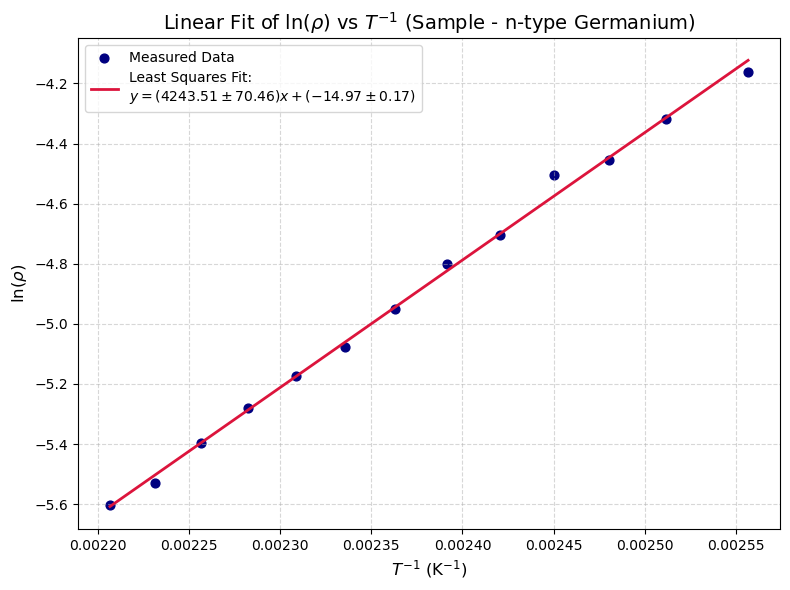

In [287]:
T_inv2 = 1/T2
S = 0.2e-2
W = 0.3e-3
rho = ((V_2)*np.pi*W)/(np.log(2)*4.8e-3)
x = T_inv2
y = np.log(rho)
n = len(x)

# --- Data Table ---
table_data = PrettyTable(["i", "x", "y", "x²", "xy"])
for i in range(n):
    table_data.add_row([i+1, round(x[i], 5), round(y[i], 5), round(x[i]**2, 7), round(x[i]*y[i], 5)])
table_data.add_row(["Σ", round(np.sum(x), 5), round(np.sum(y), 5), round(np.sum(x**2), 5), round(np.sum(x*y), 5)])
table_data.title = "Input Data"
print(table_data, "\n")

# --- Least Squares Calculation ---
Sx = np.sum(x)
Sy = np.sum(y)
Sxx = np.sum(x**2)
Sxy = np.sum(x*y)

delta = n*Sxx - Sx**2
a1 = (n*Sxy - Sx*Sy) / delta  # Slope
a0 = (Sxx*Sy - Sx*Sxy) / delta  # Intercept

# --- Error Analysis ---
y_fit = a0 + a1*x
residuals = y - y_fit
sigma_y = np.sqrt(np.sum(residuals**2) / (n-2))
sigma_a1 = sigma_y * np.sqrt(n / delta)
sigma_a0 = sigma_y * np.sqrt(Sxx / delta)

# --- Results Table ---
results = PrettyTable(["Parameter", "Value", "Uncertainty"])
results.title = "Fit Results & Statistical Errors"
results.add_row(["Slope (a₁)", f"{a1:.2f}", f"±{sigma_a1:.2f}"])
results.add_row(["Intercept (a₀)", f"{a0:.2f}", f"±{sigma_a0:.2f}"])
results.add_row(["σ_y (Std. Error)", f"{sigma_y:.2f}", ""])
results.add_row(["Δ (delta)", f"{delta:.2f}", ""])
print(results, "\n")

# --- Fitted Values Table ---
fit_table = PrettyTable(["x", "y (measured)", "y (fit)"])
fit_table.title = "Measured vs Fitted Values"
for xi, yi, yfi in zip(x, y, y_fit):
    fit_table.add_row([round(xi, 5), round(yi, 5), round(yfi, 5)])
print(fit_table, "\n")

# --- Plotting ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='navy', label='Measured Data', s=40)
plt.plot(x, y_fit, color='crimson', linewidth=2,
         label=f'Least Squares Fit:\n$y = ({a1:.2f} \pm {sigma_a1:.2f})x + ({a0:.2f} \pm {sigma_a0:.2f})$')
plt.xlabel(r'$T^{-1}$ (K$^{-1}$)', fontsize=12)
plt.ylabel(r'$\ln(\rho)$', fontsize=12)
plt.title(r"Linear Fit of $\ln(\rho)$ vs $T^{-1}$ (Sample - n-type Germanium)", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

[0.81582483 0.82942191 0.85661607 0.91100439 0.81582483 0.77503358
 0.7614365  0.77503358 0.74783942 0.87021315 1.06057227]


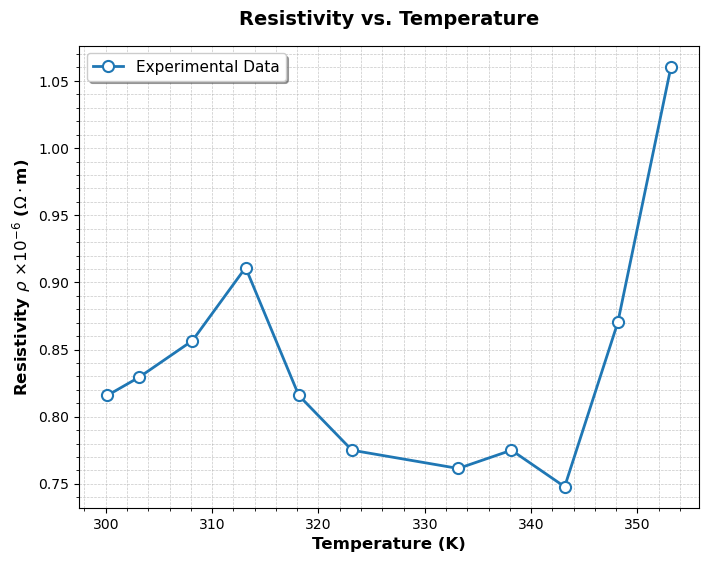

In [288]:
T3 = T3
W = 0.3e-3
V_3 = V_3*1e-3
rho = ((V_3*10)*np.pi*W)/np.log(2)
rho = rho*1e6
print(rho)


plt.figure(figsize=(8, 6))
# Plotting the data with professional styling
plt.plot(T3, rho, marker='o', linestyle='-', color='#1f77b4', 
         linewidth=2, markersize=8, markerfacecolor='white', markeredgewidth=1.5, label='Experimental Data')
plt.title('Resistivity vs. Temperature', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Temperature (K)', fontsize=12, fontweight='bold')
plt.ylabel(r'Resistivity $\rho$ $\times 10^{-6}$ ($\Omega\cdot$m)', fontsize=12, fontweight='bold')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.minorticks_on()
plt.legend(loc='best', fontsize=11, frameon=True, shadow=True)
plt.show()

+----------------------------------------+
|               Input Data               |
+----+--------+-----+-----------+--------+
| i  |   x    |  y  |     x²    |   xy   |
+----+--------+-----+-----------+--------+
| 1  | 300.2  | 0.8 |  90090.0  | 244.9  |
| 2  | 303.2  | 0.8 |  91899.9  | 251.4  |
| 3  | 308.2  | 0.9 |  94956.4  | 264.0  |
| 4  | 313.2  | 0.9 |  98062.9  | 285.3  |
| 5  | 318.2  | 0.8 |  101219.4 | 259.6  |
| 6  | 323.2  | 0.8 |  104425.9 | 250.5  |
| 7  | 333.2  | 0.8 |  110988.9 | 253.7  |
| 8  | 338.2  | 0.8 |  114345.4 | 262.1  |
| 9  | 343.2  | 0.7 |  117751.9 | 256.6  |
| 10 | 348.2  | 0.9 |  121208.4 | 303.0  |
| 11 | 353.2  | 1.1 |  124714.9 | 374.5  |
| Σ  | 3581.6 | 9.2 | 1169664.2 | 3005.4 |
+----+--------+-----+-----------+--------+ 

+-------------------------------------------+
|      Fit Results & Statistical Errors     |
+------------------+----------+-------------+
|    Parameter     |  Value   | Uncertainty |
+------------------+----------+---------

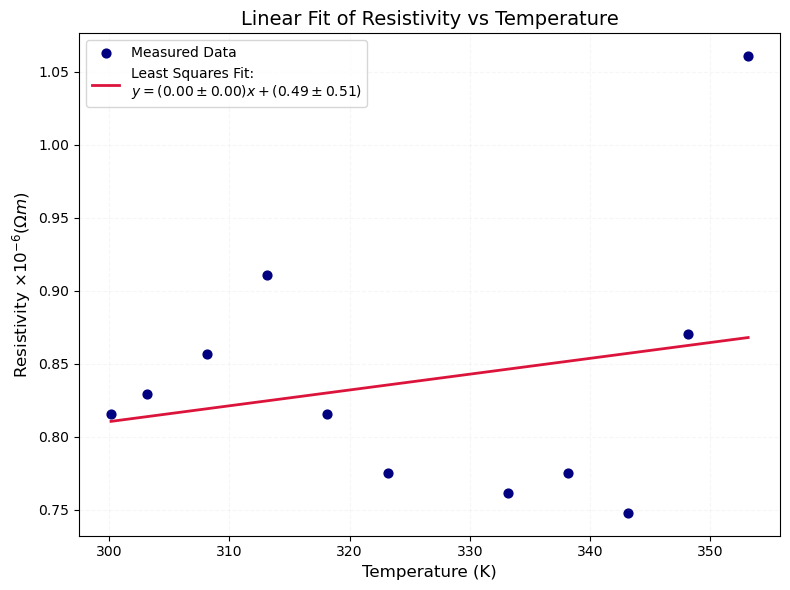

In [289]:
x = T3
y = rho 
n = len(x)

# --- Data Table ---
table_data = PrettyTable(["i", "x", "y", "x²", "xy"])
for i in range(n):
    table_data.add_row([i+1, round(x[i], 1), round(y[i], 1), round(x[i]**2, 1), round(x[i]*y[i], 1)])
table_data.add_row(["Σ", round(np.sum(x), 1), round(np.sum(y), 1), round(np.sum(x**2), 1), round(np.sum(x*y), 1)])
table_data.title = "Input Data"
print(table_data, "\n")

# --- Least Squares Calculation ---
Sx = np.sum(x)
Sy = np.sum(y)
Sxx = np.sum(x**2)
Sxy = np.sum(x*y)

delta = n*Sxx - Sx**2
a1 = (n*Sxy - Sx*Sy) / delta  # Slope
a0 = (Sxx*Sy - Sx*Sxy) / delta  # Intercept

# --- Error Analysis ---
y_fit = a0 + a1*x
residuals = y - y_fit
sigma_y = np.sqrt(np.sum(residuals**2) / (n-2))
sigma_a1 = sigma_y * np.sqrt(n / delta)
sigma_a0 = sigma_y * np.sqrt(Sxx / delta)

# --- Results Table ---
results = PrettyTable(["Parameter", "Value", "Uncertainty"])
results.title = "Fit Results & Statistical Errors"
results.add_row(["Slope (a₁)", f"{a1:.2f}", f"±{sigma_a1:.2f}"])
results.add_row(["Intercept (a₀)", f"{a0:.2f}", f"±{sigma_a0:.2f}"])
results.add_row(["σ_y (Std. Error)", f"{sigma_y:.2f}", ""])
results.add_row(["Δ (delta)", f"{delta:.2f}", ""])
print(results, "\n")

# --- Fitted Values Table ---
fit_table = PrettyTable(["x", "y (measured)", "y (fit)"])
fit_table.title = "Measured vs Fitted Values"
for xi, yi, yfi in zip(x, y, y_fit):
    fit_table.add_row([round(xi, 1), round(yi, 1), round(yfi, 1)])
print(fit_table, "\n")

# --- Plotting ---
plt.figure(figsize=(8,6))
plt.scatter(x, y, color='navy', label='Measured Data', s=40)
plt.plot(x, y_fit, color='crimson', linewidth=2,
         label=f'Least Squares Fit:\n$y = ({a1:.2f} \pm {sigma_a1:.2f})x + ({a0:.2f} \pm {sigma_a0:.2f})$')
plt.xlabel(r'Temperature (K)', fontsize=12)
plt.ylabel(r'Resistivity $ \times 10^{-6} (\Omega m) $', fontsize=12)
plt.title(r"Linear Fit of Resistivity vs Temperature", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.1)
plt.tight_layout()
plt.show()